## Experiment Tutorial: Two Qubits

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration,
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.experiment.experiment import Experiment
from qsopt.core.loss_functions import DetectionMetric

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [2]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width

interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=list(np.array([2.0, 2.0])*gm),
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 8.0])/inverse_pulse_width) 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0, 0.0]
  Dephasing rate:       [0.0, 0.0]
  Relaxation rate:      [0.0, 0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [3]:
from qsopt.core.gates import CNOTGate as CNOT

# Create Circuit with 4 rotation angles
initial_circuit = create_ry_circuit(n_qubits=2,
        theta_values= np.pi/2)
final_circuit = create_ry_circuit(n_qubits=2,
        theta_values= -np.pi/2)
#final_circuit.add_entangling_layer(CNOT, 'circular')

detection_metric = DetectionMetric(n_qubits=2, detection_criterion = 'max distance')

import optax
optimizer = optax.sgd(learning_rate=1.)

print(initial_circuit)
print(final_circuit)

QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=1.5708)
  1: RY[1](param=1.5708)
QuantumCircuit(2 qubits, 2 gates)
  0: RY[0](param=-1.5708)
  1: RY[1](param=-1.5708)


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [4]:
experiment = Experiment(exp_params, initial_circuit, final_circuit, detection_metric)

## 4. Run Basic Simulation

In [5]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1, debug=True)

print(callback)


Debug times for each step:
initialize_solvers               :  1.145286
get_measurements                 :  0.000022
get_circuits                     :  0.924272
start_measurement_loop           :  0.000004
start_simulation_with0           :  0.000004
load_cached_parameters0          :  0.000013
start_simulation0                :  0.000149
measurement0:solver_0            :  5.469918
measurement0:measure_0           :  0.116900
returning_simulation0            :  0.000038
start_simulation_no0             :  0.000005
load_cached_parameters0          :  0.000014
start_simulation0                :  0.000148
measurement0:solver_0            :  0.911326
measurement0:measure_0           :  0.000295
returning_simulation0            :  0.000034
compute_probs                    :  0.045121
save_callback                    :  0.001288

Tempo totale di simulazione = 8.614839792251587


MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
    

## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [6]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=1,
    initial_values=[1,0.75,-0.8,-1.7],
    renormalize_grad=False,
    optimizer=optax.adam(learning_rate=0.8)
)


Configuration:
    Max iterations: 10
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: max distance
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.000  rad (57.3°)
        param1.  setup_RY[1]  = 0.750  rad (43.0°)
        param2.  reset_RY[0]  = -0.800 rad (-45.8°)
        param3.  reset_RY[1]  = -1.700 rad (-97.4°)
Step  setup0_RY[0]   setup1_RY[1]   reset0_RY[0]   reset1_RY[1]   Contrast    Grad Norm   Time
---------------------------------------------------------------------------
0     1.000000       0.750000       -0.800000      -1.700000      0.758362    4.46e-01    00h00m28s
1     0.200000       1.549998       -0.000000      -1.700000      0.971305    1.25e-01    00h00m43s
2     -0.528843      0.990109       0.536047       -2.295309      0.618956    6.74e-01    00h00m58s
3     -1.289425      0.421216       0.910714       -2.889995      0.829910    4.48e-01    00h01m1

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


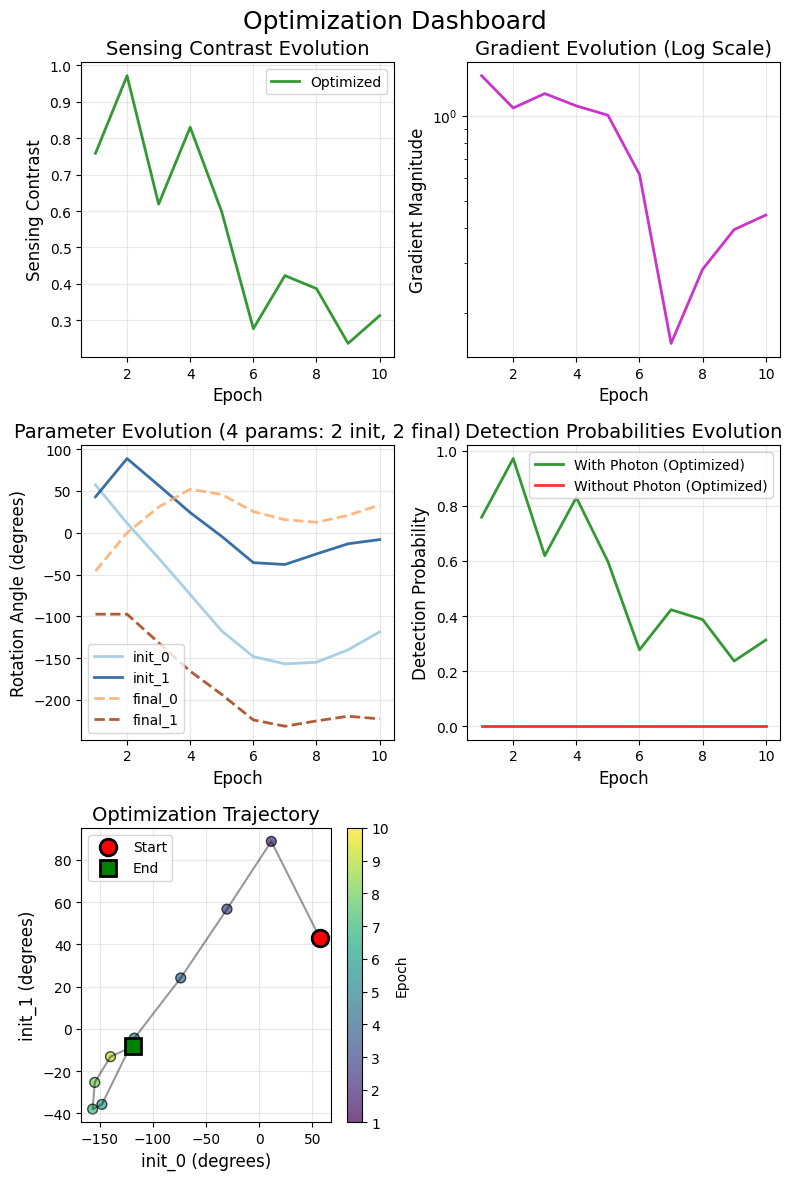

In [7]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(8, 12)
)
plt.show()
